In [2]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import hist

from models import carl, taylr
from physics.simulation import mcfm, msq
from physics.analysis import zz4l, zpair
from physics.hstar import c6

import torch
from torch.utils.data import TensorDataset, DataLoader
import lightning as L

In [3]:
JOB_DIR = '../jobs/'
SAMPLE_DIR = '../../data'

CARL_JOB = 'qqZZ-vs-SBI-05'
CARL_CKPT = [58,0.68]
TAYLR_JOB = 'refactor-eight-SBI-3M'
TAYLR_CKPT = [[178,0.05],['06',0.15],[83,0.01],[187,0.03]]

SAMPLE_FILE_ggZZ = 'ggZZ2e2m_sbi.csv'
SAMPLE_FILE_qqZZ = 'qqZZ2e2m.csv'

CARL_PATH = os.path.join(JOB_DIR, 'carl', CARL_JOB)
CARL_CKPT_PATH = os.path.join(CARL_PATH, 'checkpoints', f'checkpoint-carl-epoch={CARL_CKPT[0]}-val_loss={CARL_CKPT[1]}.ckpt')
TAYLR_PATH = os.path.join(JOB_DIR, 'taylr', TAYLR_JOB)
TAYLR_CKPT_PATHs = [os.path.join(TAYLR_PATH, f'coeff_{i+1}','checkpoints', f'checkpoint-taylr-epoch={TAYLR_CKPT[i][0]}-val_loss={TAYLR_CKPT[i][1]}.ckpt') for i in range(len(TAYLR_CKPT))]
SAMPLE_PATH_ggZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_ggZZ)
SAMPLE_PATH_qqZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_qqZZ)

In [69]:
SAMPLE_SIZE = 10000

luminosity = 3000

FEATURES = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

BATCH_SIZE = 512

C6_LINSPACE = [-23,23,415]
CH_LINSPACE = [-0.02,0.02,50]

C6_VAL_DATA = 0

SEED = 42

In [2]:
xs = {'ggZZ': 1.5569109*4, 'qqZZ': 14.482054*4}

In [3]:
print(xs)

{'ggZZ': 6.2276436, 'qqZZ': 57.928216}


In [6]:
events_ggZZ = mcfm.from_csv(cross_section=xs['ggZZ'], file_path=SAMPLE_PATH_ggZZ, n_rows=SAMPLE_SIZE*1.2)
events_qqZZ = mcfm.from_csv(cross_section=xs['qqZZ'], file_path=SAMPLE_PATH_qqZZ, n_rows=SAMPLE_SIZE*1.2)

zcandidates = zpair.ZPairCandidate(algorithm='leastsquare')
zmasses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
lepton_momenta = zz4l.LeptonMomenta()
fourlep = zz4l.FourLeptonSystem()
m4l_filter = zz4l.M4l(0,np.inf)

events_ggZZ_processed = events_ggZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta).calculate(fourlep).filter(m4l_filter)
events_qqZZ_processed = events_qqZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta).calculate(fourlep).filter(m4l_filter)

sigma_ggZZ = events_ggZZ_processed.weights.sum()
sigma_qqZZ = events_qqZZ_processed.weights.sum()

0.0643227034393
0.6244181517293901


In [7]:
c6_mod = c6.Modifier(baseline=msq.Component.SBI, events=events_ggZZ_processed, c6_values=[-5,-1,0,1,5])
c6_weights, c6_prob = c6_mod.modify(c6=np.linspace(*C6_LINSPACE))#C6_VAL_DATA)

In [8]:
c6_index = np.where(np.linspace(*C6_LINSPACE)==C6_VAL_DATA)[0][0]
c6_zero_index = np.where(np.linspace(*C6_LINSPACE)==0.0)[0][0]

In [9]:
true_probs = np.array([np.concatenate([c6_weights[:SAMPLE_SIZE//2,i], events_qqZZ_processed[:SAMPLE_SIZE//2].weights]) for i in range(c6_weights.shape[1])])
true_probs /= np.sum(true_probs, axis=1)[:, np.newaxis]

In [10]:
# ggZZ + qqZZ

#events_final = mcfm.Process(pd.concat([events_ggZZ_processed.kinematics[:SAMPLE_SIZE//2], events_qqZZ_processed.kinematics[:SAMPLE_SIZE//2]],ignore_index=True).reset_index(drop=True),
#                            pd.concat([events_ggZZ_processed.components[:SAMPLE_SIZE//2], events_qqZZ_processed.components[:SAMPLE_SIZE//2]],ignore_index=True).reset_index(drop=True),
#                            pd.concat([pd.Series(c6_weights[:,c6_index].flatten()).reset_index(drop=True)[:SAMPLE_SIZE//2]*np.sum(c6_weights[:,c6_index])/np.sum(c6_weights[:SAMPLE_SIZE//2, c6_index]), events_qqZZ_processed.weights[:SAMPLE_SIZE//2].reset_index(drop=True)*sigma_qqZZ/events_qqZZ_processed.weights[:SAMPLE_SIZE//2].sum()],ignore_index=True).reset_index(drop=True))

In [11]:
# This is for ggZZ only

events_final = mcfm.Process(events_ggZZ_processed.kinematics.reset_index(drop=True)[:SAMPLE_SIZE],
                            events_ggZZ_processed.components.reset_index(drop=True)[:SAMPLE_SIZE],
                            pd.Series(c6_weights[:,c6_index].flatten()).reset_index(drop=True)[:SAMPLE_SIZE]*np.sum(c6_weights[:,c6_index])/np.sum(c6_weights[:SAMPLE_SIZE,c6_index]))
                        #   Fixing the cross section to remain the same after cutting events to SAMPLE_SIZE

In [12]:
sigma_data = events_final.weights.sum()

In [13]:
kinematics = events_final.kinematics[FEATURES]

In [14]:
model_carl = carl.CARL.load_from_checkpoint(checkpoint_path=CARL_CKPT_PATH)

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:758: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [15]:
models_taylr = [taylr.TAYLR.load_from_checkpoint(checkpoint_path=path) for path in TAYLR_CKPT_PATHs]

In [16]:
with open(os.path.join(CARL_PATH, 'scaler.pkl'), 'rb') as f:
    scaler_carl = pickle.load(f)

X_carl = scaler_carl.transform(kinematics.to_numpy())
dl_carl = DataLoader(TensorDataset(torch.tensor(X_carl, dtype=torch.float32)), batch_size=BATCH_SIZE, num_workers=15)

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [17]:
m4l = events_final.kinematics[['4l_mass']].to_numpy().flatten()
indices = np.arange(len(m4l))
probabilities = np.concatenate([events_ggZZ_processed[:SAMPLE_SIZE//2].probabilities.to_numpy(), events_qqZZ_processed[:SAMPLE_SIZE//2].probabilities.to_numpy()], axis=0)

bins = 60
bounds = [180,1000]
step_size = (bounds[1]-bounds[0])/bins

labels = np.concatenate([np.zeros(SAMPLE_SIZE//2), np.ones(SAMPLE_SIZE//2)], axis=0)

prob_binned = [probabilities[(m4l >= bounds[0]+step_size*i)&(m4l < bounds[0] + step_size*(i+1))] for i in range(bins)]
labels_binned = [labels[(m4l >= bounds[0]+step_size*i)&(m4l < bounds[0] + step_size*(i+1))] for i in range(bins)]
indices_binned = [indices[(m4l >= bounds[0]+step_size*i)&(m4l < bounds[0] + step_size*(i+1))] for i in range(bins)]

sig_sum = np.array([np.sum(prob_binned[i][labels_binned[i]==1.0]) for i in range(bins)])
bkg_sum = np.array([np.sum(prob_binned[i][labels_binned[i]==0.0]) for i in range(bins)])

ratios_binned = sig_sum/bkg_sum

r_histo = np.zeros(len(m4l))
for i in range(bins):
    for ind in indices_binned[i]:
        r_histo[ind] = ratios_binned[i]

/tmp/ipykernel_288208/3356211520.py:18: RuntimeWarning: divide by zero encountered in divide
  ratios_binned = sig_sum/bkg_sum
/tmp/ipykernel_288208/3356211520.py:18: RuntimeWarning: invalid value encountered in divide
  ratios_binned = sig_sum/bkg_sum


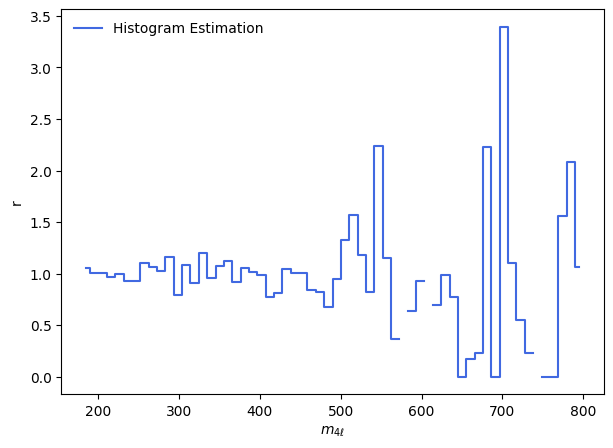

In [18]:
bins = 60

bounds = [180,800]
step_size = (bounds[1]-bounds[0])/bins

#r_binned = [np.mean(r[(m4l >= bounds[0]+step_size*i)&(m4l < bounds[0] + step_size*(i+1))]) for i in range(bins)]
#r_binned_std = [np.std(r[(m4l >= bounds[0]+step_size*i)&(m4l < bounds[0] + step_size*(i+1))]) for i in range(bins)]

centers = [step_size * (i + 1/2) + bounds[0] for i in range(bins)]

fig = plt.figure(figsize=(7,5))

#plt.errorbar(centers, r_binned, yerr=r_binned_std, drawstyle='steps-mid', color='red', label='CARL')
plt.errorbar(centers, ratios_binned, linestyle='-', drawstyle='steps-mid', color='royalblue', label='Histogram Estimation')

plt.ylabel('r')
plt.xlabel('$m_{4\ell}$')

plt.legend(frameon=False)

plt.show()

In [19]:
trainer = L.Trainer(accelerator='cpu')

pred_carl = torch.concatenate(trainer.predict(model_carl, dl_carl)).numpy()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 20/20 [00:06<00:00,  3.06it/s]


In [20]:
r = pred_carl/(1-pred_carl)


##### CARL calibration 

In [21]:
ggZZ_wt_SM = events_ggZZ_processed[:SAMPLE_SIZE//2].weights.to_numpy() * sigma_ggZZ/events_ggZZ_processed[:SAMPLE_SIZE//2].weights.sum()

R = 1/sigma_ggZZ * np.sum(ggZZ_wt_SM * r[:SAMPLE_SIZE//2])

r /= R

In [22]:
cut_inds = np.where((np.log(r) >= -0.5)&(np.log(r) < 0.7))

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_288208/1033722428.py:21: RuntimeWarning: invalid value encountered in divide
  truth_ratios = sig_per_bin/(bkg_per_bin + sig_per_bin)
/tmp/ipykernel_288208/1033722428.py:23: RuntimeWarning: invalid value encountered in divide
  truth_ratios_dev = np.sqrt((sig_dev/bkg_per_bin)**2 + (-bkg_dev*sig_per_bin/bkg_per_bin**2)**2)
/home/iws

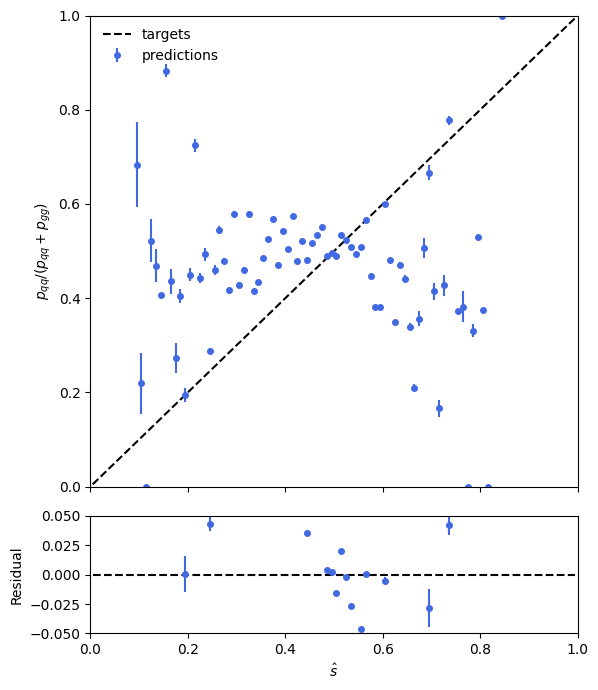

In [23]:
bins = 100
bounds = [-3,3]
bounds = [0,1]
step_size = (bounds[1]-bounds[0])/bins

weights = np.concatenate([events_ggZZ_processed[:SAMPLE_SIZE//2].probabilities.to_numpy(), events_qqZZ_processed[:SAMPLE_SIZE//2].probabilities.to_numpy()], axis=0)

p = r/(1+r)
t = np.concatenate([np.zeros(len(r)//2), np.ones(len(r)//2)], axis=0)

pred_binned = [p[(p > bounds[0]+step_size*i) & (p <= bounds[0]+step_size*(i+1))] for i in range(bins)]
targets_binned = [t[(p > bounds[0]+step_size*i) & (p <= bounds[0]+step_size*(i+1))] for i in range(bins)]
weights_binned = [weights[(p > bounds[0]+step_size*i) & (p <= bounds[0]+step_size*(i+1))] for i in range(bins)]

sig_per_bin = np.array([np.sum(weights_binned[i][targets_binned[i]==1.0]) for i in range(bins)])
bkg_per_bin = np.array([np.sum(weights_binned[i][targets_binned[i]==0.0]) for i in range(bins)])

sig_dev = np.array([np.std(weights_binned[i][targets_binned[i]==1.0]) for i in range(bins)])
bkg_dev = np.array([np.std(weights_binned[i][targets_binned[i]==0.0]) for i in range(bins)])

truth_ratios = sig_per_bin/(bkg_per_bin + sig_per_bin)
#truth_ratios = sig_per_bin/bkg_per_bin
truth_ratios_dev = np.sqrt((sig_dev/bkg_per_bin)**2 + (-bkg_dev*sig_per_bin/bkg_per_bin**2)**2)
truth_ratios_dev = np.sqrt((sig_dev * bkg_per_bin/(sig_per_bin + bkg_per_bin)**2)**2 + (-bkg_dev*sig_per_bin/(sig_per_bin + bkg_per_bin)**2)**2)
#truth_ratios_dev = np.sqrt(( sig_dev/sig_per_bin )**2 + ( bkg_dev/bkg_per_bin )**2)

pred_ratios_avg = [np.mean(pred_binned[i]) for i in range(bins)]

centers = np.array([bounds[0]+(i+1/2)*step_size for i in range(bins)])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4,1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.errorbar(centers, centers, color='black', linestyle='--', label='targets')
ax1.errorbar(centers, truth_ratios, yerr=truth_ratios_dev, color='royalblue', marker='o', markersize=4, linestyle='none', label='predictions')

ax1.set_xlim(*bounds)
ax1.set_ylim(*bounds)
ax1.set_ylabel('$p_{qq}/(p_{qq}+p_{gg})$')

ax1.legend(frameon=False)

ax2.errorbar(centers, np.array(centers)-np.array(centers), color='black', linestyle='--', label='targets')
ax2.errorbar(centers, np.array(truth_ratios)-np.array(centers), yerr=truth_ratios_dev, color='royalblue', marker='o', markersize=4, linestyle='none', label='predictions')

ax2.set_xlim(*bounds)
ax2.set_xlabel('$\hat{s}$')
ax2.set_ylabel('Residual')
ax2.set_ylim(-5e-2,5e-2)

plt.tight_layout()
plt.show()

In [24]:
dls_taylr = []
for i in range(len(TAYLR_CKPT)):
    with open(os.path.join(TAYLR_PATH, f'coeff_{i+1}', 'scaler_X.pkl'), 'rb') as f:
        scaler_X = pickle.load(f)
    X_taylr = scaler_X.transform(kinematics.to_numpy())
    dl = DataLoader(TensorDataset(torch.tensor(X_taylr, dtype=torch.float32)), batch_size=BATCH_SIZE, num_workers=15)
    dls_taylr.append(dl)

In [25]:
coeffs_pred = []

for i in range(len(TAYLR_CKPT)):
    with open(os.path.join(TAYLR_PATH, f'coeff_{i+1}', 'scaler_y.pkl'), 'rb') as f:
        scaler_y = pickle.load(f)
    coeffs_pred.append(scaler_y.inverse_transform(torch.concatenate(trainer.predict(models_taylr[i], dls_taylr[i])).numpy()[:,np.newaxis]).flatten())

coeffs_pred = np.array(coeffs_pred).T

Predicting DataLoader 0: 100%|██████████| 20/20 [00:03<00:00,  6.16it/s]


In [26]:
coeffs_true = c6_mod.coefficients[:SAMPLE_SIZE,1:]

In [27]:
def histplot_RP(coeff_ind, ax, color, label, bounds, bins, coeffs, weights):
    h = hist.Hist(hist.axis.Regular(bins, *bounds), storage=hist.storage.Weight())
    h.fill(coeffs[:,coeff_ind], weight=weights)

    h.plot(ax=ax, color=color, label=label)

def compare_hists_RP(coeff_index, ax, coeffs, weights, bounds, bins=60, colors=['royalblue', 'red'], labels=['ggZZ', 'qqZZ']):
    histplot_RP(coeff_index, ax, colors[0], labels[0], bounds, bins, coeffs[0], weights[0])
    histplot_RP(coeff_index, ax, colors[1], labels[1], bounds, bins, coeffs[1], weights[1])

    ax.set_xlim(*bounds)
    ax.legend(frameon=False)
    ax.set_xlabel(f'coeff {coeff_index+1}')
    ax.set_ylabel('probability')
    ax.set_yscale('log')

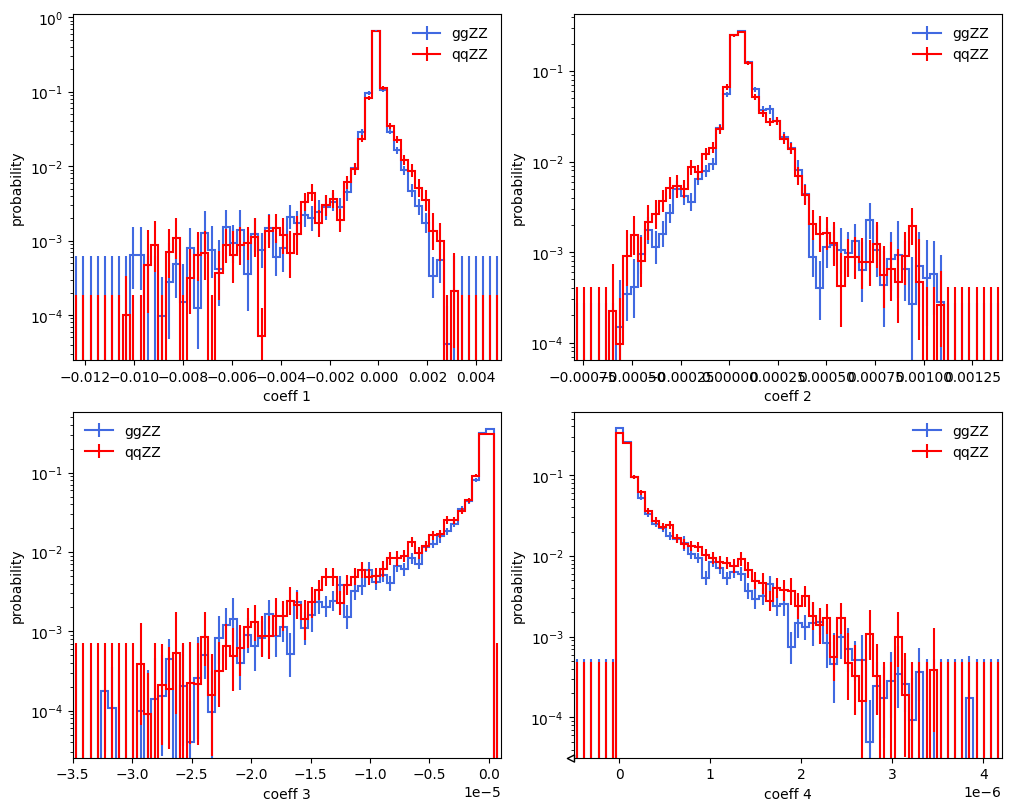

In [28]:
bins = 60

fig, axes = plt.subplots(2,2, figsize=(10,8), layout='constrained')


coeffs_tuple = (coeffs_pred[:SAMPLE_SIZE//2], coeffs_pred[SAMPLE_SIZE//2:])
probs_tuple = (events_ggZZ_processed[:SAMPLE_SIZE//2].probabilities, events_qqZZ_processed[:SAMPLE_SIZE//2].probabilities)

compare_hists_RP(0, axes[0,0], coeffs_tuple, probs_tuple, [-1.25e-2, 5e-3], bins)
compare_hists_RP(1, axes[0,1], coeffs_tuple, probs_tuple, [-8e-4, 1.4e-3], bins)
compare_hists_RP(2, axes[1,0], coeffs_tuple, probs_tuple, [-3.5e-5, 1e-6], bins)
compare_hists_RP(3, axes[1,1], coeffs_tuple, probs_tuple, [-5e-7, 4.2e-6], bins)

plt.show()

In [29]:
c6_values = np.linspace(*C6_LINSPACE)

In [30]:
def f(c6_values, coeffs):
    coefficients = np.concatenate([np.ones((len(coeffs),1)), coeffs], axis=1)
    c6_matrix = np.vander(c6_values, coefficients.shape[1], increasing=True).T
    return np.dot(coefficients, c6_matrix).T

In [31]:
sigma_ggZZ_BSM = np.sum(ggZZ_wt_SM[np.newaxis,:] * f(c6_values, coeffs_pred[:SAMPLE_SIZE//2]), axis=1)
sigma_ggZZ_BSM_true = np.sum(ggZZ_wt_SM[np.newaxis,:] * f(c6_values, coeffs_true[:SAMPLE_SIZE//2]), axis=1)
# This works because the order of events in events_ggZZ_processed and events_final is the same (for the first SAMPLE_SIZE//2 events)

In [32]:
# Comment out the sigma_qqZZ terms if performing on ggZZ only

full_SM_xs = sigma_ggZZ #+ sigma_qqZZ

full_BSM_xs = sigma_ggZZ_BSM #+ sigma_qqZZ 

nu_SM = full_SM_xs * luminosity
nu = full_BSM_xs * luminosity

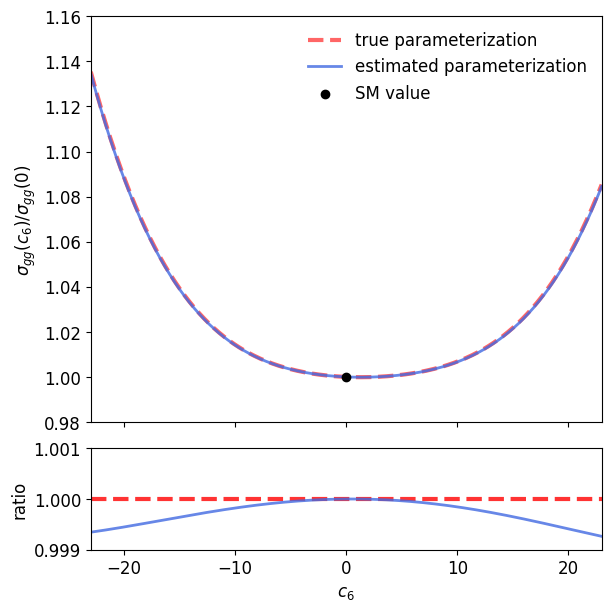

In [33]:
fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4,1]}, figsize=(6,6), layout='constrained')


ax1.plot(c6_values, sigma_ggZZ_BSM_true/sigma_ggZZ, color='red', ls='--', zorder=1, lw=3, label=f'true parameterization', alpha=0.6)
ax1.plot(c6_values, sigma_ggZZ_BSM/sigma_ggZZ, color='royalblue', zorder=2, lw=2, label=f'estimated parameterization', alpha=0.8)
ax1.scatter(0, 1, color='k', marker='o', zorder=2, label='SM value')

ax1.set_ylim(ax1.get_yticks()[0],ax1.get_yticks()[-1])
ax1.set_ylabel('$\sigma_{gg}(c_6)/\sigma_{gg}(0)$', fontsize=12)

ax1.tick_params(labelsize=12)
ax1.set_xticklabels([])
ax1.set_xlim(*C6_LINSPACE[:2])

ax1.legend(frameon=False, loc='upper right', fontsize=12)

ax2.plot(c6_values, sigma_ggZZ_BSM_true/sigma_ggZZ_BSM_true, color='red', lw=3, ls='--', zorder=1, alpha=0.8)
ax2.plot(c6_values, sigma_ggZZ_BSM/sigma_ggZZ_BSM_true, color='royalblue', lw=2, zorder=2, alpha=0.8)

ax2.tick_params(labelsize=12)
ax2.set_xlabel('$c_6$', fontsize=12)
ax2.set_ylim(0.999,1.001)
ax2.set_xlim(*C6_LINSPACE[:2])
ax2.set_ylabel('ratio', fontsize=12)

plt.show()

In [34]:
print(f'XS minimum at c6={c6_values[np.argmin(sigma_ggZZ_BSM)]:0.2f}')

XS minimum at c6=1.33


In [35]:
N_data = sigma_data*luminosity

# Poisson term
t_1 = - 2 * N_data * (np.log(nu) - np.log(nu_SM)) + 2 * (nu - nu_SM) 

In [36]:
# true ratios for ggZZ only
p_num = (c6_weights[:SAMPLE_SIZE]/np.sum(c6_weights[:SAMPLE_SIZE], axis=0))
p_den = (c6_weights[:SAMPLE_SIZE,c6_zero_index]/np.sum(c6_weights[:SAMPLE_SIZE,c6_zero_index], axis=0))[:,np.newaxis]

p_ratio_truth_ggZZ = p_num / p_den

In [37]:
#t_2 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:] + np.log(p_ratio_truth_ggZZ.T), axis=1)

In [38]:
#p_ratio = sigma_ggZZ/full_BSM_xs[:,np.newaxis] * (f(c6_values, coeffs_pred) + sigma_qqZZ/sigma_ggZZ*r)

In [39]:
p_ratio = full_SM_xs/full_BSM_xs[:,np.newaxis] * (f(c6_values, coeffs_pred) + sigma_qqZZ/sigma_ggZZ*r)/(1 + sigma_qqZZ/sigma_ggZZ * r)

In [40]:
rescaling_factor = np.sum(p_ratio * true_probs[c6_zero_index,:], axis=1)

p_ratio_fixed = p_ratio/rescaling_factor[:,np.newaxis]

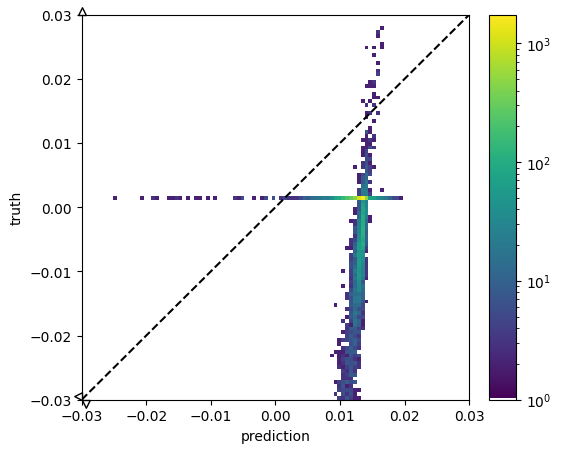

In [41]:
BINS=100

c6_val = -10
c6_val_index = np.where(np.linspace(*C6_LINSPACE) == c6_val)[0][0]

bounds = {-20: [-2e-1,5e-2],
          -10: [-3e-2,3e-2],
          -1:  [-3e-3,1e-3],
          0:   [-1e-10,1e-10],
          1:   [-5e-4,5e-4],
          10:  [-8e-3,8e-3],}[c6_val]

h_calibration_val = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name=f'prediction'),
    hist.axis.Regular(BINS, *bounds, name='truth')
)

h_calibration_val.fill(-np.log(p_ratio)[c6_val_index,:], -np.log(true_probs[c6_val_index,:]/true_probs[c6_zero_index,:]))

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_calibration_val.plot2d(cmap=cmap, cbar=True, norm=colors.LogNorm())
plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

#plt.text(10,10,f'c6={c6_val}')

plt.show()

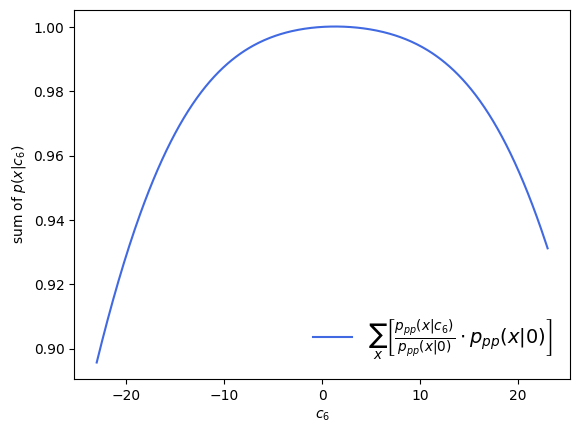

In [42]:
plt.plot(c6_values, rescaling_factor, color='royalblue', label='$\sum_{x}\left[\\frac{p_{pp}(x|c_6)}{p_{pp}(x|0)}\cdot p_{pp}(x|0)\\right]$')
plt.legend(frameon=False, fontsize=14)

plt.xlabel('$c_6$')
plt.ylabel('sum of $p(x|c_6)$')

plt.show()

In [43]:
# Used for ggZZ + qqZZ
#p_ratio = sigma_ggZZ/full_BSM_xs[:,np.newaxis] * (f(c6_values, coeffs_pred) + sigma_qqZZ/sigma_ggZZ*r)

t_3 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:] * np.log(p_ratio_fixed), axis=1)

In [44]:
# Used for ggZZ only
t_2 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:] * np.log(sigma_ggZZ/sigma_ggZZ_BSM[:,np.newaxis] * f(c6_values, coeffs_pred)), axis=1)

In [45]:
t = t_1 + t_2

In [46]:
t_min = c6_values[np.argmin(t)]

In [47]:
# Print top ten lowest values
print(c6_values[np.argsort(t)[:10]])
print(t[np.argsort(t)[:10]])

[ 0.22222222  0.11111111  0.33333333  0.          0.44444444 -0.11111111
  0.55555556 -0.22222222  0.66666667 -0.33333333]
[-1.07541063e-03 -1.01827712e-03 -2.06645897e-04 -1.22357486e-11
  1.55472096e-03  2.01663119e-03  4.17732575e-03  5.07080969e-03
  7.63172179e-03  9.20373087e-03]


In [48]:
ci = np.sort(np.round(c6_values[np.argsort(np.abs(t-(np.min(t)+1)))[:2]], 2))
ci_2 = np.sort(np.round(c6_values[np.argsort(np.abs(t-(np.min(t)+4)))[:2]], 2))

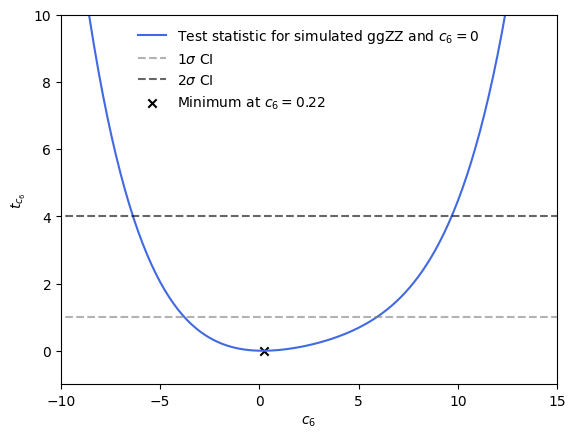

In [49]:
plt.plot(c6_values, t, color='royalblue', label=f'Test statistic for simulated ggZZ and $c_6 = {C6_VAL_DATA}$')
plt.hlines(np.min(t)+1, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], linestyle='--', color='grey', alpha=0.6, label=f'$1\sigma$ CI')# [{ci[0]},{ci[1]}]')
plt.hlines(np.min(t)+4, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], linestyle='--', color='k', alpha=0.6, label=f'$2\sigma$ CI')# [{ci_2[0]},{ci_2[1]}]')
plt.scatter(t_min, np.min(t), color='k', marker='x', label=f'Minimum at $c_6 = {round(t_min,2)}$')

#plt.scatter([-4.8,8.3,-7.4,11.5],[np.min(t)+1,np.min(t)+1,np.min(t)+4,np.min(t)+4], c='k', marker='x') # CI for ggZZ

plt.xlabel('$c_6$')
plt.ylabel('$t_{c_6}$')
plt.ylim(-1,10)
plt.xlim(-10,15)
#plt.yscale('log')

plt.legend(frameon=False)
plt.show()

In [70]:
cH_values = np.linspace(*CH_LINSPACE)

In [71]:
t_1_c6 = - 2 * N_data * (np.log(nu[:,np.newaxis] - 2*cH_values[np.newaxis,:] * nu_SM) - np.log(nu_SM)) + 2 * (nu[:,np.newaxis] - 2*cH_values[np.newaxis,:] * nu_SM - nu_SM) 

In [72]:
t_2_c6 = -2 * luminosity * np.sum(events_final.weights.to_numpy()[np.newaxis,:,np.newaxis] * np.log(sigma_ggZZ/(sigma_ggZZ_BSM[:,np.newaxis,np.newaxis] - 2*cH_values[np.newaxis,np.newaxis,:] * sigma_ggZZ) * (f(c6_values, coeffs_pred)[:,:,np.newaxis] - 2*cH_values[np.newaxis,np.newaxis,:])), axis=1)

In [73]:
t_c6 = t_1_c6 + t_2_c6

In [75]:
c6_min_ind = np.argmin(t_c6)//CH_LINSPACE[2]
cH_min_ind = np.argmin(t_c6)%CH_LINSPACE[2]

t_min_c6 = t_c6[c6_min_ind,cH_min_ind]

In [76]:
t_min_c6

0.00975839814722077

In [77]:
X, Y = np.meshgrid(np.linspace(*C6_LINSPACE), np.linspace(*CH_LINSPACE))
Z = t_c6.T

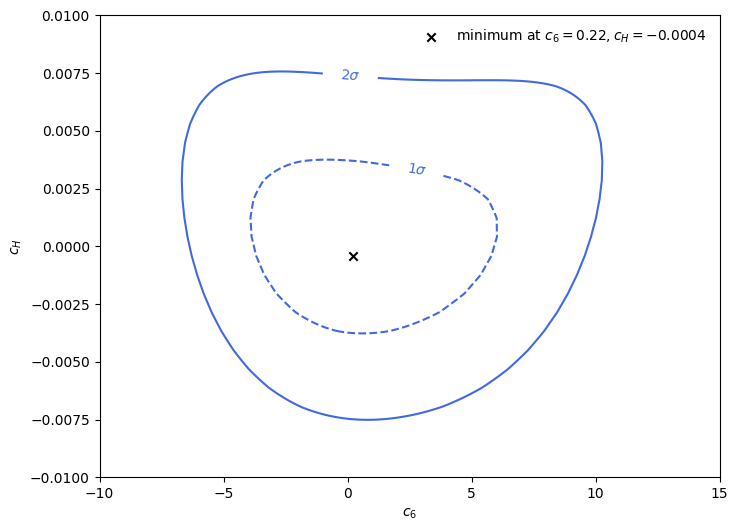

In [78]:
plt.figure(figsize=(8, 6))
contours = plt.contour(X, Y, Z, levels=[t_min_c6+1,t_min_c6+4], colors='royalblue', linestyles=['--','-'])
plt.clabel(contours, fmt=dict(zip([t_min_c6+1,t_min_c6+4], ['$1\sigma$', '$2\sigma$'])))

plt.scatter(np.linspace(*C6_LINSPACE)[c6_min_ind], np.linspace(*CH_LINSPACE)[cH_min_ind], marker='x', color='k',label=f'minimum at $c_6={np.linspace(*C6_LINSPACE)[c6_min_ind]:0.2f}, c_H ={np.linspace(*CH_LINSPACE)[cH_min_ind]:0.4f}$')

plt.legend(frameon=False)

plt.xlabel('$c_6$')
plt.ylabel('$c_H$')

plt.xlim(-10,15)
plt.ylim(-0.01,0.01)


plt.show()